In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.37MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.65MB/s]


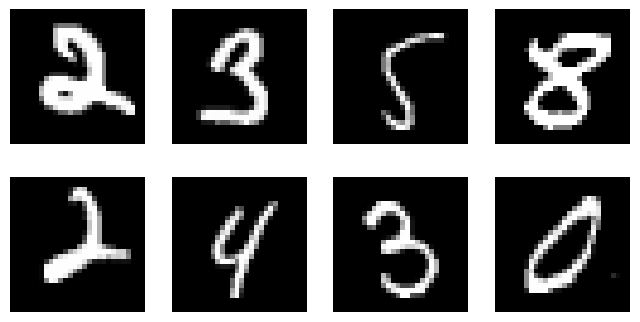

In [ ]:
examples = next(iter(train_loader))
images, labels = examples

plt.figure(figsize=(8,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.axis('off')
plt.show()


In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 400),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decoder(z)
        return reconstruction, mu, logvar


In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(
        recon_x, x.view(-1, 784), reduction='sum'
    )

    KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KL


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

for epoch in range(epochs):
    total_loss = 0
    for data, _ in train_loader:
        data = data.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = vae_loss(recon, data, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset)}")

Epoch 1, Loss: 190.02561572265626
Epoch 2, Loss: 167.8571481282552
Epoch 3, Loss: 163.8347671549479
Epoch 4, Loss: 160.94319129231772
Epoch 5, Loss: 159.1384730794271
Epoch 6, Loss: 157.87740615234375
Epoch 7, Loss: 156.8678321451823
Epoch 8, Loss: 156.0973096516927
Epoch 9, Loss: 155.43527150065106
Epoch 10, Loss: 154.83746292317707


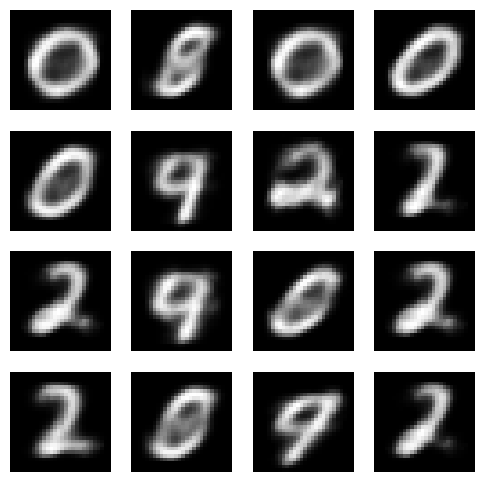

In [ ]:
with torch.no_grad():
    z = torch.randn(16, 2).to(device)
    generated = model.decoder(z).cpu()

plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(generated[i].view(28,28), cmap='gray')
    plt.axis('off')
plt.show()

In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(generator.parameters(), lr=0.0002)
opt_D = optim.Adam(discriminator.parameters(), lr=0.0002)

epochs = 10
z_dim = 100

for epoch in range(epochs):
    for real, _ in train_loader:
        real = real.view(-1, 784).to(device)

        # Train Discriminator
        noise = torch.randn(real.size(0), z_dim).to(device)
        fake = generator(noise)

        real_loss = criterion(discriminator(real), torch.ones(real.size(0),1).to(device))
        fake_loss = criterion(discriminator(fake.detach()), torch.zeros(real.size(0),1).to(device))

        loss_D = real_loss + fake_loss
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        loss_G = criterion(discriminator(fake), torch.ones(real.size(0),1).to(device))
        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch+1}, D Loss: {loss_D.item()}, G Loss: {loss_G.item()}")

Epoch 1, D Loss: 0.12499037384986877, G Loss: 5.569070339202881
Epoch 2, D Loss: 0.6960780620574951, G Loss: 3.4523448944091797
Epoch 3, D Loss: 1.7999255657196045, G Loss: 1.2172975540161133
Epoch 4, D Loss: 0.3089684844017029, G Loss: 3.4246535301208496
Epoch 5, D Loss: 0.10035141557455063, G Loss: 4.630736827850342
Epoch 6, D Loss: 0.3700256943702698, G Loss: 7.183343410491943
Epoch 7, D Loss: 0.4607282280921936, G Loss: 4.306454658508301
Epoch 8, D Loss: 0.19773219525814056, G Loss: 4.452666759490967
Epoch 9, D Loss: 0.2105584442615509, G Loss: 5.057494163513184
Epoch 10, D Loss: 0.27684059739112854, G Loss: 5.203613758087158


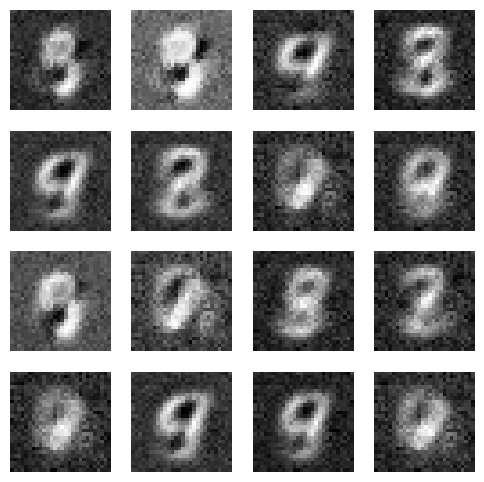

In [ ]:
with torch.no_grad():
    noise = torch.randn(16, z_dim).to(device)
    fake = generator(noise).cpu()

plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(fake[i].view(28,28), cmap='gray')
    plt.axis('off')
plt.show()

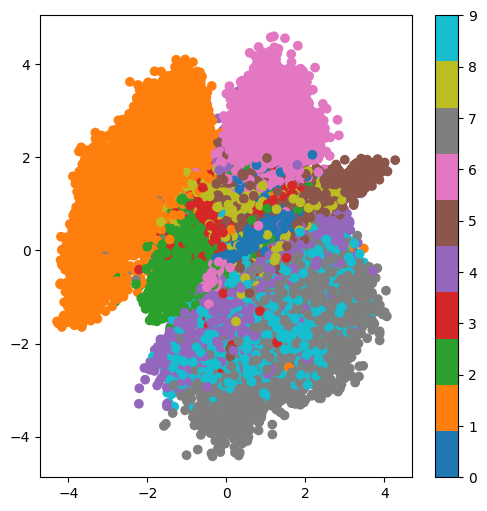

In [ ]:
latent_vectors = []
labels_list = []

with torch.no_grad():
    for data, labels in train_loader:
        data = data.to(device)
        _, mu, _ = model(data)
        latent_vectors.append(mu.cpu())
        labels_list.append(labels)

latent_vectors = torch.cat(latent_vectors)
labels_list = torch.cat(labels_list)

plt.figure(figsize=(6,6))
plt.scatter(latent_vectors[:,0], latent_vectors[:,1], c=labels_list, cmap='tab10')
plt.colorbar()
plt.show()

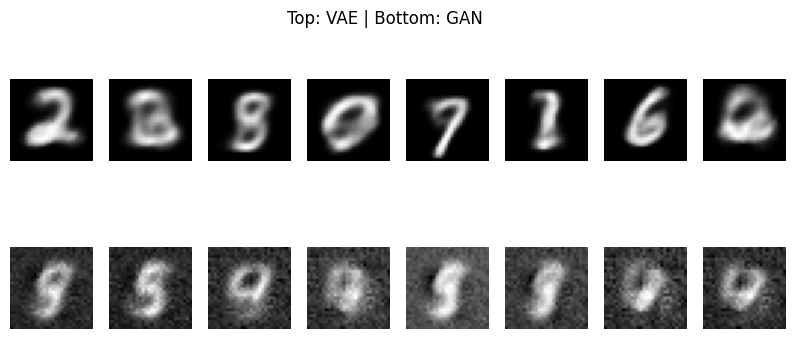

In [ ]:
# Generate VAE images
with torch.no_grad():
    z = torch.randn(8, 2).to(device)
    vae_images = model.decoder(z).cpu()

# Generate GAN images
with torch.no_grad():
    noise = torch.randn(8, 100).to(device)
    gan_images = generator(noise).cpu()

# Plot Comparison
plt.figure(figsize=(10,4))

for i in range(8):
    plt.subplot(2,8,i+1)
    plt.imshow(vae_images[i].view(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2,8,i+9)
    plt.imshow(gan_images[i].view(28,28), cmap='gray')
    plt.axis('off')

plt.suptitle("Top: VAE | Bottom: GAN")
plt.show()